In [2]:
!pip install webdataset --quiet

In [1]:
import sys, pathlib
ROOT = pathlib.Path('.').resolve().parent
sys.path.insert(0, str(ROOT / 'src'))

from config import mount_drive
mount_drive()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Experiment 01 - Baseline CNN

**Goal:** Establish the performance floor with a minimal 2-block CNN, no augmentation.  
**Model:** `BaselineCNN`
**Metric (primary):** Macro-F1 on the held-out test set  
**Augmentation:** None (eval transform only -> resize + normalize)do n  

Results from this notebook define the baseline that all subsequent experiments must beat.

In [3]:
import torch
from config import load_config
from augmentation import build_eval_transform
from dataset import build_dataloaders
from model import BaselineCNN
from training import Trainer, compute_class_weights
from utils import set_seed, show_results, load_model

cfg = load_config(ROOT / 'content/configs/config.yaml')
set_seed(cfg.preprocessing.random_seed, cfg.device)
print(f'Device: {cfg.device} | Dataset: {cfg.dataset_variant} | Classes: {len(cfg.classes)}')

[config] environment: colab
Device: cuda | Dataset: mini | Classes: 37


In [4]:
EXP_NAME = 'baseline'
num_classes = len(cfg.classes)

# No augmentation for baseline - eval transform on all splits isolates model capacity
eval_tf = build_eval_transform(cfg.preprocessing.image_size, use_imagenet_norm=False)

train_loader, val_loader, test_loader = build_dataloaders(
    train_transform=eval_tf,
    eval_transform=eval_tf,
    **cfg.dataloader_kwargs(),
)
print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

Train batches: 2  Val: 3  Test: 3


In [5]:
model = BaselineCNN(in_channels=3, num_classes=num_classes)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'BaselineCNN - Trainable params: {n_params:,}')

BaselineCNN - Trainable params: 155,365



  Experiment: baseline
  Device: cuda  |  AMP: True  |  Epochs: 30
  [DEBUG] _train_epoch start | OS=Linux | Python=3.12.13
  [DEBUG] DataLoader num_workers=2  batch_size=128
  [DEBUG] Creating iterator (if stuck here -> multiprocessing deadlock)...


  Train E1:   0%|          | 0/2 [00:00<?, ?it/s]

  [DEBUG] Iterator created, entering batch loop...
  [DEBUG] First batch received: inputs=(128, 3, 224, 224) labels=(128,)


  [DEBUG] _val_epoch start | num_workers=2


  [DEBUG] _val_epoch done
Epoch 001/30  train_loss=3.6123  train_acc=0.0195  val_loss=3.6109  val_acc=0.0110  val_F1=0.0026  [11.9s]
  New best val macro-F1=0.0026 - checkpoint saved
  [DEBUG] _train_epoch start | OS=Linux | Python=3.12.13
  [DEBUG] DataLoader num_workers=2  batch_size=128
  [DEBUG] Creating iterator (if stuck here -> multiprocessing deadlock)...


...

  [DEBUG] _val_epoch done
Epoch 022/30  train_loss=2.6787  train_acc=0.2500  val_loss=3.4767  val_acc=0.1096  val_F1=0.0803  [4.8s]
  [DEBUG] _train_epoch start | OS=Linux | Python=3.12.13
  [DEBUG] DataLoader num_workers=2  batch_size=128
  [DEBUG] Creating iterator (if stuck here -> multiprocessing deadlock)...


  Train E23:   0%|          | 0/2 [00:00<?, ?it/s]

  [DEBUG] Iterator created, entering batch loop...
  [DEBUG] First batch received: inputs=(128, 3, 224, 224) labels=(128,)


  [DEBUG] _val_epoch start | num_workers=2


  [DEBUG] _val_epoch done
Epoch 023/30  train_loss=2.6616  train_acc=0.2383  val_loss=3.4722  val_acc=0.1205  val_F1=0.0948  [3.2s]
  Early stopping triggered at epoch 23.


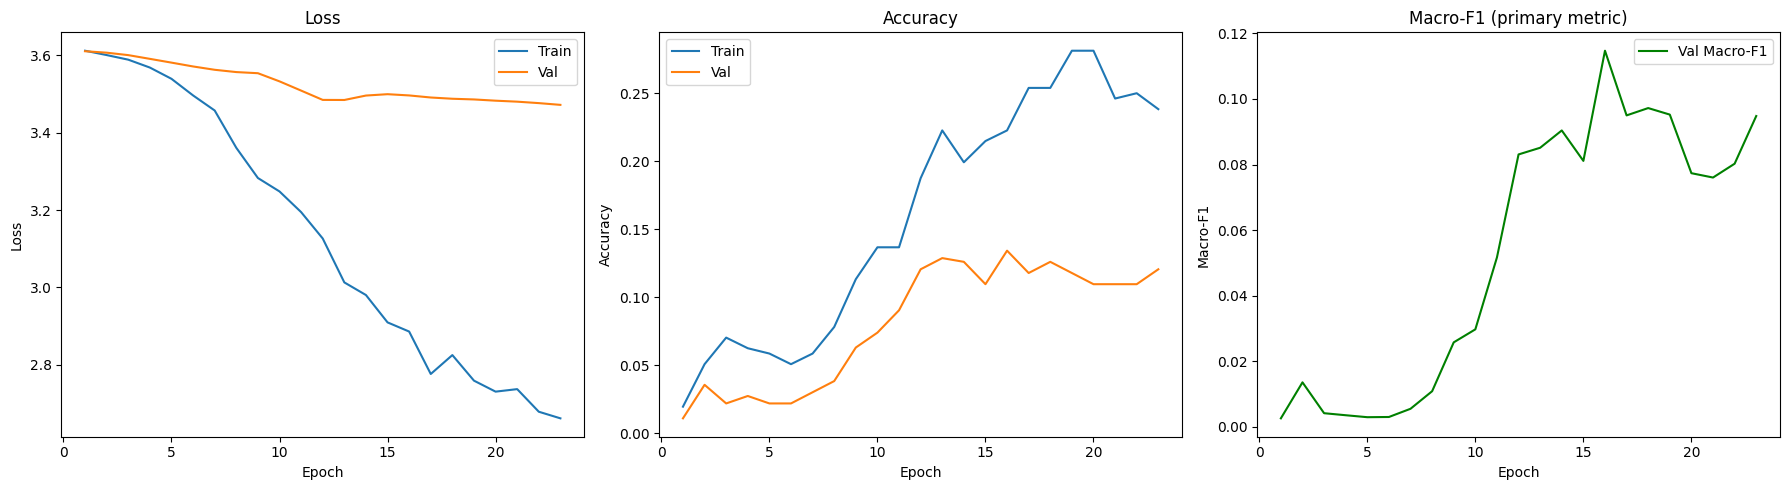

In [6]:
class_weights = compute_class_weights(cfg.class_weight_source, num_classes) if cfg.training.use_class_weights else None

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=cfg.device,
    exp_name=EXP_NAME,
    results_root=cfg.results_root,
    checkpoints_root=cfg.checkpoints_root,
    num_epochs=cfg.training.num_epochs,
    learning_rate=cfg.training.learning_rate,
    weight_decay=cfg.training.weight_decay,
    grad_clip=cfg.training.grad_clip,
    grad_accum_steps=cfg.training.grad_accum_steps,
    early_stopping_patience=cfg.training.early_stopping_patience,
    use_amp=cfg.training.use_amp,
    scheduler=cfg.training.scheduler,
    class_weights=class_weights,
    num_classes=num_classes,
)

history = trainer.train()

Test Loss:      3.5344
Test Accuracy:  0.1067
Test Macro-F1:  0.0754  (primary metric)
Balanced Acc:   0.1071


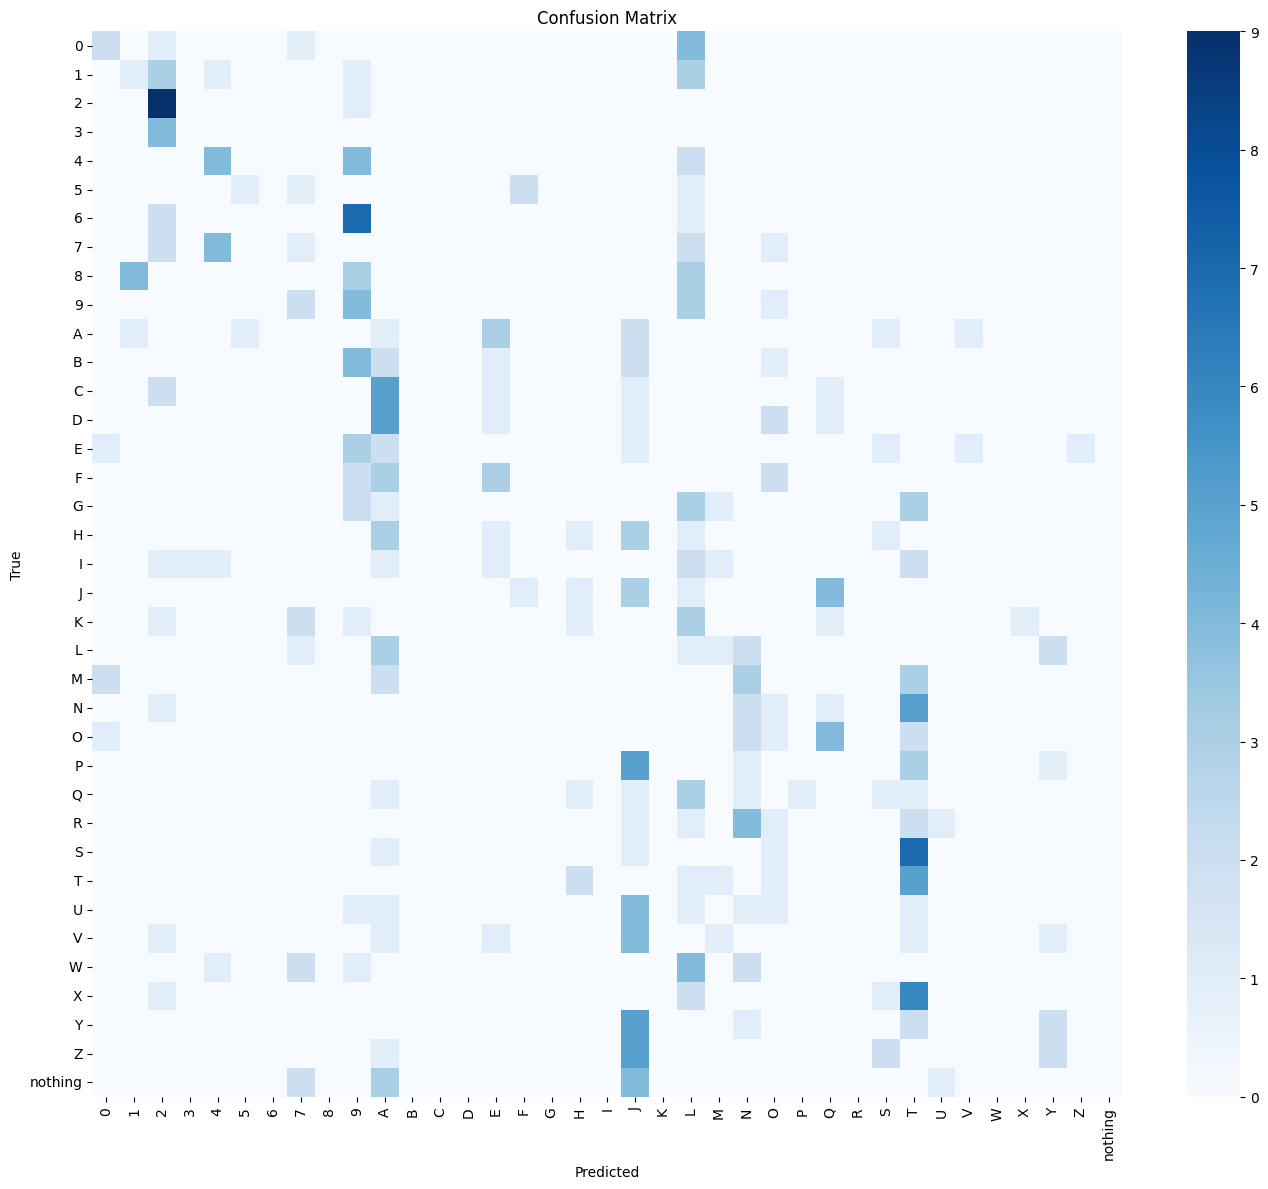

Macro-F1: 0.0754   Balanced Acc: 0.1071

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.25      0.29         8
           1       0.17      0.11      0.13         9
           2       0.32      0.90      0.47        10
           3       0.00      0.00      0.00         4
           4       0.36      0.40      0.38        10
           5       0.50      0.20      0.29         5
           6       0.00      0.00      0.00        10
           7       0.08      0.10      0.09        10
           8       0.00      0.00      0.00        10
           9       0.12      0.40      0.18        10
           A       0.03      0.10      0.04        10
           B       0.00      0.00      0.00        10
           C       0.00      0.00      0.00        10
           D       0.00      0.00      0.00        10
           E       0.00      0.00      0.00        10
           F       0.00      0.00      0.00        10
           G     

In [7]:
import torch.nn as nn
from utils import evaluate_model

best_ckpt = cfg.checkpoints_root / EXP_NAME / 'best.pt'
model = load_model(BaselineCNN(in_channels=3, num_classes=num_classes), str(best_ckpt), cfg.device)

test_loss, test_acc, test_f1, test_bal, true_labels, pred_labels = evaluate_model(
    model, test_loader, cfg.device, nn.CrossEntropyLoss()
)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Macro-F1: {test_f1:.4f}  (primary metric)')
print(f'Balanced Acc:  {test_bal:.4f}')

show_results(true_labels, pred_labels, cfg.classes, save_dir=str(cfg.results_root / EXP_NAME))